In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler,FunctionTransformer,OrdinalEncoder,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

import warnings
warnings.filterwarnings('ignore')
import datetime


Loading Dataset

In [104]:
df = pd.read_csv('global_cars_enhanced.csv')
df.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,Car_Age,Price_Category,HP_per_CC,Age_Category,Efficiency_Score
0,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA,20,Premium,0.1338,Old,0.35
1,CAR_0002,Nissan,2023,Coupe,Petrol,Automatic,4618,167,25,79370,USA,3,Premium,0.0362,New,0.75
2,CAR_0003,Nissan,2007,Hatchback,Diesel,Manual,1802,110,16,76549,China,19,Premium,0.0610,Old,0.30
3,CAR_0004,Nissan,2013,Coupe,Petrol,Manual,1835,373,16,48722,USA,13,Mid-Range,0.2033,Old,0.30
4,CAR_0005,Hyundai,2009,Hatchback,Hybrid,Automatic,2332,145,28,83265,UK,17,Premium,0.0622,Old,0.90


EDA

In [105]:
df.shape

(300, 16)

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Car_ID                 300 non-null    object 
 1   Brand                  300 non-null    object 
 2   Manufacture_Year       300 non-null    int64  
 3   Body_Type              300 non-null    object 
 4   Fuel_Type              300 non-null    object 
 5   Transmission           300 non-null    object 
 6   Engine_CC              300 non-null    int64  
 7   Horsepower             300 non-null    int64  
 8   Mileage_km_per_l       300 non-null    int64  
 9   Price_USD              300 non-null    int64  
 10  Manufacturing_Country  300 non-null    object 
 11  Car_Age                300 non-null    int64  
 12  Price_Category         300 non-null    object 
 13  HP_per_CC              300 non-null    float64
 14  Age_Category           300 non-null    object 
 15  Effici

In [107]:
df.describe()

,Manufacture_Year,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Car_Age,HP_per_CC,Efficiency_Score
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2015.123333,3052.880000,328.346667,19.716667,60848.823333,10.876667,0.129559,0.485833
std,5.966023,1117.937497,153.202644,6.028061,34445.525598,5.966023,0.093239,0.301403
min,2005.000000,1001.000000,70.000000,10.000000,5221.000000,1.000000,0.017800,0.000000
25%,2010.000000,2074.000000,188.250000,15.000000,29418.500000,6.000000,0.063250,0.250000
50%,2015.000000,3117.500000,329.500000,19.500000,59179.500000,11.000000,0.106850,0.475000
75%,2020.000000,3964.000000,454.750000,24.000000,89692.250000,16.000000,0.168325,0.700000
max,2025.000000,4994.000000,599.000000,30.000000,119587.000000,21.000000,0.525500,1.000000


Data cleaning

In [108]:
df.isna().sum()

Car_ID                   0
Brand                    0
Manufacture_Year         0
Body_Type                0
Fuel_Type                0
Transmission             0
Engine_CC                0
Horsepower               0
Mileage_km_per_l         0
Price_USD                0
Manufacturing_Country    0
Car_Age                  0
Price_Category           0
HP_per_CC                0
Age_Category             0
Efficiency_Score         0
dtype: int64

In [109]:
df['Brand'].unique()

array(['Mercedes', 'Nissan', 'Hyundai', 'Tesla', 'Audi', 'Honda', 'Ford',
       'Toyota', 'BMW', 'Kia'], dtype=object)

In [110]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'Hybrid', 'Electric'], dtype=object)

In [111]:
df['Body_Type'].unique()

array(['SUV', 'Coupe', 'Hatchback', 'Sedan', 'Pickup'], dtype=object)

In [112]:
df['Manufacture_Year'].unique()

array([2006, 2023, 2007, 2013, 2009, 2012, 2011, 2016, 2017, 2020, 2025,
       2019, 2014, 2010, 2005, 2022, 2021, 2024, 2008, 2018, 2015])

In [113]:
df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [114]:
df['Manufacturing_Country'].unique()

array(['USA', 'China', 'UK', 'Japan', 'Germany', 'South Korea'],
      dtype=object)

In [115]:
df['Price_Category'].unique()

array(['Premium', 'Mid-Range', 'Budget', 'Luxury'], dtype=object)

In [116]:
df['Age_Category'].unique()

array(['Old', 'New', 'Moderate', 'Recent'], dtype=object)

In [163]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'Hybrid', 'Electric'], dtype=object)

Data visualization

<Axes: >

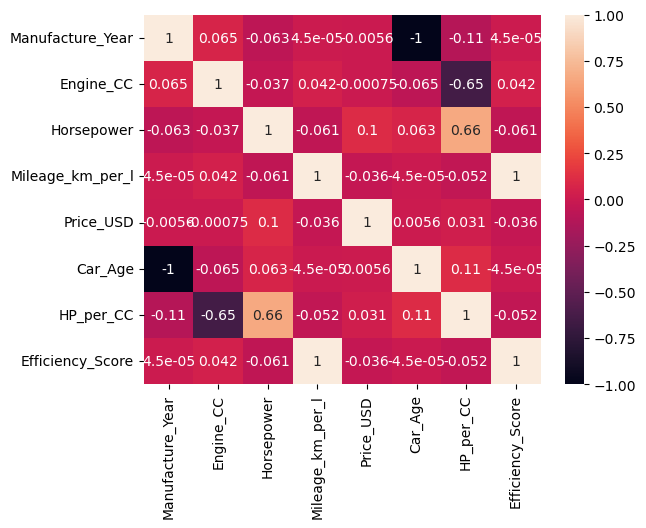

In [117]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [119]:
df.corr(numeric_only=True)['Price_USD'].sort_values(ascending=False)

Price_USD           1.000000
Horsepower          0.104940
HP_per_CC           0.030636
Car_Age             0.005602
Engine_CC          -0.000749
Manufacture_Year   -0.005602
Mileage_km_per_l   -0.035517
Efficiency_Score   -0.035517
Name: Price_USD, dtype: float64

<Axes: xlabel='Mileage_km_per_l', ylabel='Price_USD'>

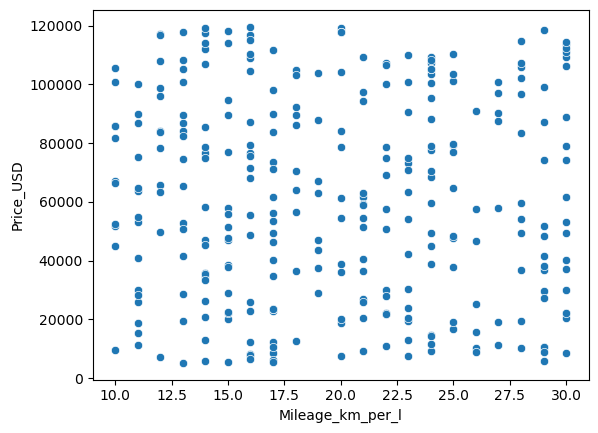

In [121]:
sns.scatterplot(data=df,x='Mileage_km_per_l',y='Price_USD')

<Axes: xlabel='Price_USD', ylabel='Count'>

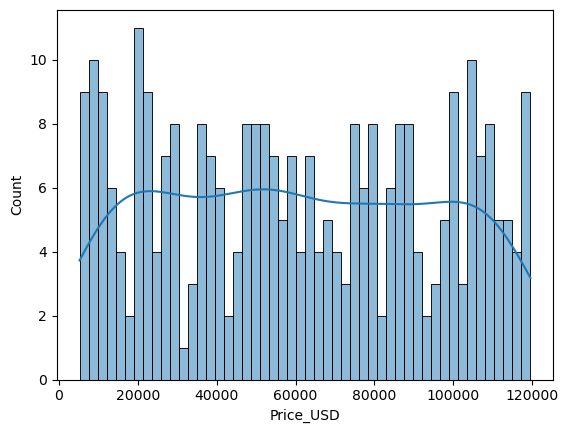

In [122]:
sns.histplot(df['Price_USD'],bins=50,kde=True)

<Axes: xlabel='Transmission', ylabel='Price_USD'>

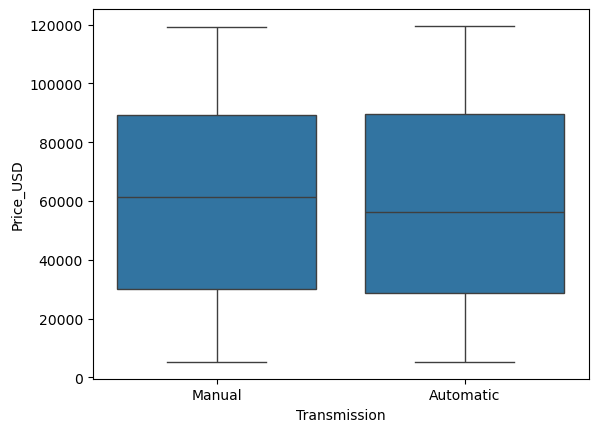

In [123]:
sns.boxplot(data=df,x='Transmission',y='Price_USD')

<Axes: xlabel='Manufacturing_Country', ylabel='count'>

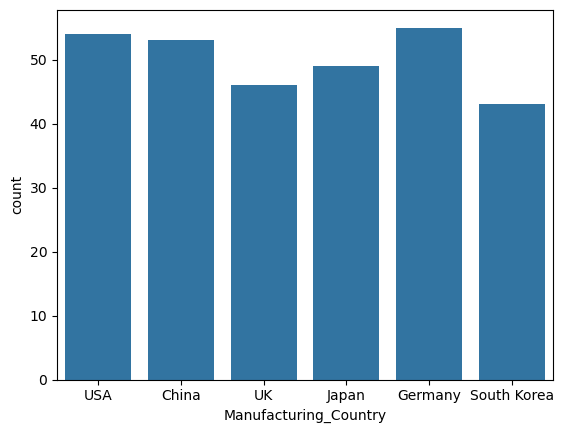

In [ ]:
sns.countplot(x=df['Manufacturing_Country'])

<Axes: xlabel='Body_Type', ylabel='count'>

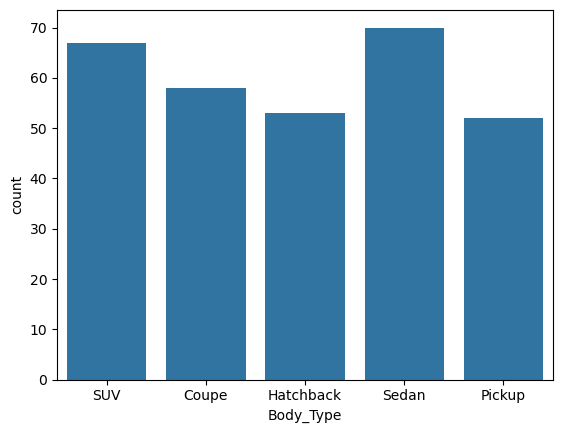

In [ ]:
sns.countplot(x=df['Body_Type'])

<Axes: xlabel='Fuel_Type', ylabel='count'>

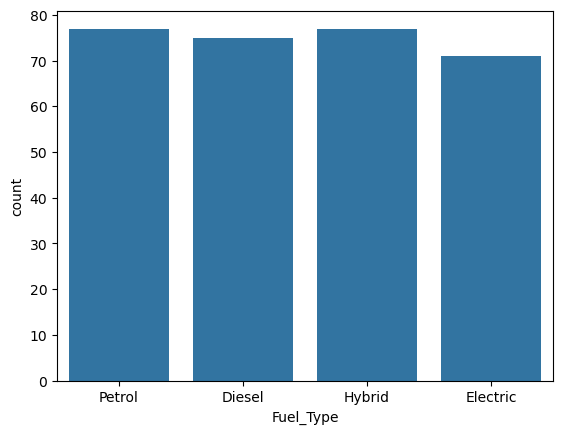

In [ ]:
sns.countplot(x=df['Fuel_Type'])

<Axes: xlabel='Price_Category', ylabel='count'>

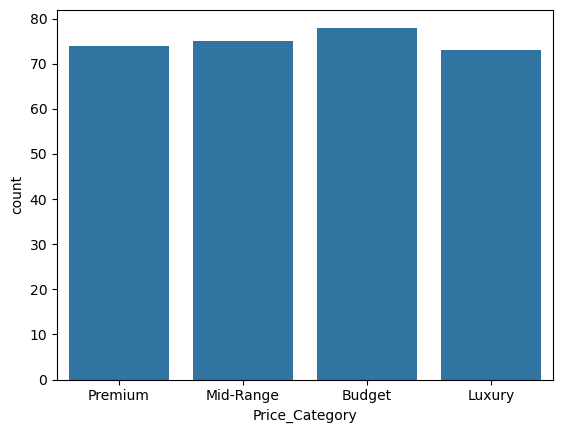

In [ ]:
sns.countplot(x=df['Price_Category'])

Checking outliers

In [124]:
num_features=df.select_dtypes(include='number')
Q1= num_features.quantile(0.25)
Q3= num_features.quantile(0.75)
IQR= Q3-Q1
lower_bound= Q1-1.5*IQR
upper_bound= Q3+1.5*IQR

outliers= (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Manufacture_Year     0
Engine_CC            0
Horsepower           0
Mileage_km_per_l     0
Price_USD            0
Car_Age              0
HP_per_CC           11
Efficiency_Score     0
dtype: int64


Checking skewness

In [125]:
num_cols= df.select_dtypes(include='number')
num_cols.skew()

Manufacture_Year   -0.054341
Engine_CC          -0.045520
Horsepower          0.046678
Mileage_km_per_l    0.163901
Price_USD           0.041312
Car_Age             0.054341
HP_per_CC           1.502178
Efficiency_Score    0.163901
dtype: float64

Spliting data

In [126]:
df.columns

Index(['Car_ID', 'Brand', 'Manufacture_Year', 'Body_Type', 'Fuel_Type',
       'Transmission', 'Engine_CC', 'Horsepower', 'Mileage_km_per_l',
       'Price_USD', 'Manufacturing_Country', 'Car_Age', 'Price_Category',
       'HP_per_CC', 'Age_Category', 'Efficiency_Score'],
      dtype='object')

In [130]:
df.shape

(300, 16)

Train test split

In [147]:
skewwd_col= ['HP_per_CC']
other_numeric_cols=['Manufacture_Year','Engine_CC', 'Horsepower', 'Mileage_km_per_l','Car_Age','Efficiency_Score']
normal_col= ['Brand','Body_Type', 'Fuel_Type','Transmission','Price_Category']

feature_col= skewwd_col + other_numeric_cols + normal_col
X= df[feature_col]
y= df['Price_USD']

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.30,random_state=42)

In [162]:
X.columns.to_list()

['HP_per_CC',
 'Manufacture_Year',
 'Engine_CC',
 'Horsepower',
 'Mileage_km_per_l',
 'Car_Age',
 'Efficiency_Score',
 'Brand',
 'Body_Type',
 'Fuel_Type',
 'Transmission',
 'Price_Category']

Preprocessing using columntransformer

In [148]:
skew_pipeline=Pipeline(steps=[
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scale',StandardScaler())
])

plane_numeric_pipeline=Pipeline(steps=[
    ('scale',StandardScaler())
])


nominal_pipeline= Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor= ColumnTransformer(transformers=[
    ("Skewed_Pipeline",skew_pipeline,skewwd_col),
    ("Plane_Numeric",plane_numeric_pipeline,other_numeric_cols),
    ("Normal",nominal_pipeline,normal_col)
])

Model tunning

linear regression

In [149]:
lr_pipeline= Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('resgressor',LinearRegression())
])

lr_pipeline.fit(X_train,y_train)
lr_pred= lr_pipeline.predict(X_test)
lr_pred_train= lr_pipeline.predict(X_train)

lr_r2_testing= r2_score(y_test,lr_pred)
lr_r2_training= r2_score(y_train,lr_pred_train)
lr_mae= mean_absolute_error(y_test,lr_pred)

print(f"Accuracy of traning: {lr_r2_training}")
print(f"Accuracy of testing: {lr_r2_testing}")
print(f"MAE: {lr_mae}")

Accuracy of traning: 0.9493764534217307
Accuracy of testing: 0.9362778423068772
MAE: 7440.150435240179


Random forest

In [150]:
rf_pipeline= Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('random_forest',RandomForestRegressor())
])

rf_pipeline.fit(X_train,y_train)
rf_pred= rf_pipeline.predict(X_test)
rf_pred_train= rf_pipeline.predict(X_train)

rf_r2_testing= r2_score(y_test,rf_pred)
rf_r2_training= r2_score(y_train,rf_pred_train)
rf_mae= mean_absolute_error(y_test,rf_pred)

print(f"Accuracy of traning: {rf_r2_training}")
print(f"Accuracy of testing: {rf_r2_testing}")
print(f"MAE: {rf_mae}")

Accuracy of traning: 0.9901119190287396
Accuracy of testing: 0.9294203546508761
MAE: 7808.999333333334


Hyperparameter tunning of random forest

In [151]:
param_grid= {
    'random_forest__n_estimators': [100,200,300],
    'random_forest__max_depth': [5,10,15],
    'random_forest__min_samples_split': [2,5,10],
    'random_forest__min_samples_leaf': [1,2,4]
}

random_search= RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

,estimator,Pipeline(step...Regressor())])
,param_distributions,"{'random_forest__max_depth': [5, 10, ...], 'random_forest__min_samples_leaf': [1, 2, ...], 'random_forest__min_samples_split': [2, 5, ...], 'random_forest__n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [152]:
random_search.best_params_

{'random_forest__n_estimators': 200,
 'random_forest__min_samples_split': 5,
 'random_forest__min_samples_leaf': 1,
 'random_forest__max_depth': 5}

In [153]:
rf_best_pipeline= random_search.best_estimator_
rf_best_preds= rf_best_pipeline.predict(X_test)

print(f"R2: {r2_score(y_test,rf_best_preds)}")
print(f"MAE: {mean_absolute_error(y_test,rf_best_preds)}")

R2: 0.9344794213438097
MAE: 7594.136068886449


Models evalulation

In [154]:
lr_rmse= np.sqrt(mean_squared_error(y_test,lr_pred))
rf_rmse= np.sqrt(mean_absolute_error(y_test,rf_pred))

rf_tunned_preds= random_search.best_estimator_.predict(X_test)
rf_tunned_rmse= np.sqrt(mean_squared_error(y_test,rf_tunned_preds))
rf_tunned_tranining_preds= random_search.best_estimator_.predict(X_train)
r2_tunned_traninig= r2_score(y_train,rf_tunned_tranining_preds)
rf_tunned_mae= mean_absolute_error(y_test,rf_tunned_preds)
rf_tunned_r2= r2_score(y_test,rf_tunned_preds)

results= pd.DataFrame({
    'Modle' : ['Linear Regression','Rondom Forest (default)', 'Random Forest (tunned)'],
    'R2 (testing)': [lr_r2_testing,rf_r2_testing,rf_tunned_r2],
    'R2 (training)': [lr_r2_training,rf_r2_training,r2_tunned_traninig],
    "MAE": [lr_mae,rf_mae,rf_tunned_mae],
    "RMSE": [lr_rmse,rf_rmse,rf_tunned_rmse]
})

print(results)

                     Modle  R2 (testing)  R2 (training)          MAE  \
0        Linear Regression      0.936278       0.949376  7440.150435   
1  Rondom Forest (default)      0.929420       0.990112  7808.999333   
2   Random Forest (tunned)      0.934479       0.972827  7594.136069   

          RMSE  
0  8868.191309  
1    88.368543  
2  8992.463402  


Inputs

In [155]:
X.columns

Index(['HP_per_CC', 'Manufacture_Year', 'Engine_CC', 'Horsepower',
       'Mileage_km_per_l', 'Car_Age', 'Efficiency_Score', 'Brand', 'Body_Type',
       'Fuel_Type', 'Transmission', 'Price_Category'],
      dtype='object')

In [159]:
Brand = input("Enter Brand: ").strip()
Manufacture_Year = int(input("Enter Manufacture Year: "))
Body_Type = input(
    "Enter Body Type (Sedan/SUV/Hatchback/Coupe/Pickup): "
).strip()
Fuel_Type = input("Enter Fuel Type (Petrol/Diesel/Electric/Hybrid): ").strip()
Transmission = input("Enter Transmission (Manual/Automatic): ").strip()
Engine_CC = float(input("Enter Engine CC: "))
Horsepower = float(input("Enter Horsepower: "))
Mileage_km_per_l= int(input("Enter mileage: "))

# 3. Feature Engineering / Derived Columns
current_year = datetime.datetime.now().year
Car_Age = current_year - Manufacture_Year
HP_per_CC = Horsepower / Engine_CC if Engine_CC != 0 else 0

Price_Category = input(
    "Enter Price Category (Premium/Mid-Range/Budget/Luxury): "
).strip()
Age_Category = input("Enter Age Category (Old/New/Moderate/Recent): ").strip()
Efficiency_Score= float(input("Enter Efficiency Score: "))

# 4. Create the Pandas DataFrame matching the exact training column order
inputs = pd.DataFrame(
    {
        "Brand": [Brand],
        "Manufacture_Year": [Manufacture_Year],
        "Body_Type": [Body_Type],
        "Fuel_Type": [Fuel_Type],
        "Transmission": [Transmission],
        "Engine_CC": [Engine_CC],
        "Horsepower": [Horsepower],
        "Mileage_km_per_l": [Mileage_km_per_l],
        "Car_Age": [Car_Age],
        "Price_Category": [Price_Category],
        "HP_per_CC": [HP_per_CC],
        "Age_Category": [Age_Category],
        "Efficiency_Score": [Efficiency_Score]
    }
)

print("\n--- Input Details Collected ---")
print(inputs.to_string(index=False))
print("-" * 31)

# 5. Prediction Execution
try:
    # ⚠️ CRITICAL STEP:
    # If your model expects encoded numbers (OneHotEncoded/LabelEncoded),
    # you must transform 'inputs' before running predict:
    # e.g., vectorized_inputs = encoder.transform(inputs)
    # y_pred = model.predict(vectorized_inputs)

    y_pred = rf_best_pipeline.predict(inputs)

    print(f"\n🚀 Predicted Car Price: {y_pred[0]:,.2f}")

except Exception as e:
    print(f"\n❌ Prediction Failed: {e}")
    print(
        "Tip: This usually happens if your model expects numeric dummy variables (One-Hot Encoding) instead of raw text strings like 'Sedan' or 'Petrol'."
    )


--- Input Details Collected ---
   Brand  Manufacture_Year Body_Type Fuel_Type Transmission  Engine_CC  Horsepower  Mileage_km_per_l  Car_Age Price_Category  HP_per_CC Age_Category  Efficiency_Score
Mercedes              2006       SUV    Petrol       Manual     4089.0       547.0                17       20        Premium   0.133774          Old              0.35
-------------------------------

🚀 Predicted Car Price: 72,228.32


In [161]:
import joblib
joblib.dump(rf_best_pipeline,"car_price_model.pkl")

['car_price_model.pkl']